**⚙️ INSTALLATION**

In [13]:
!pip install xgboost imbalanced-learn -q

**📦 ÉTAPE 1 — CHARGEMENT DES DONNÉES**

Saving ai4i2020[1].csv to ai4i2020[1] (2).csv
  CHARGEMENT DES DONNÉES
  Fichier   : ai4i2020[1] (2).csv
  Lignes    : 10000
  Colonnes  : 14

--- 5 premières lignes ---
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0 

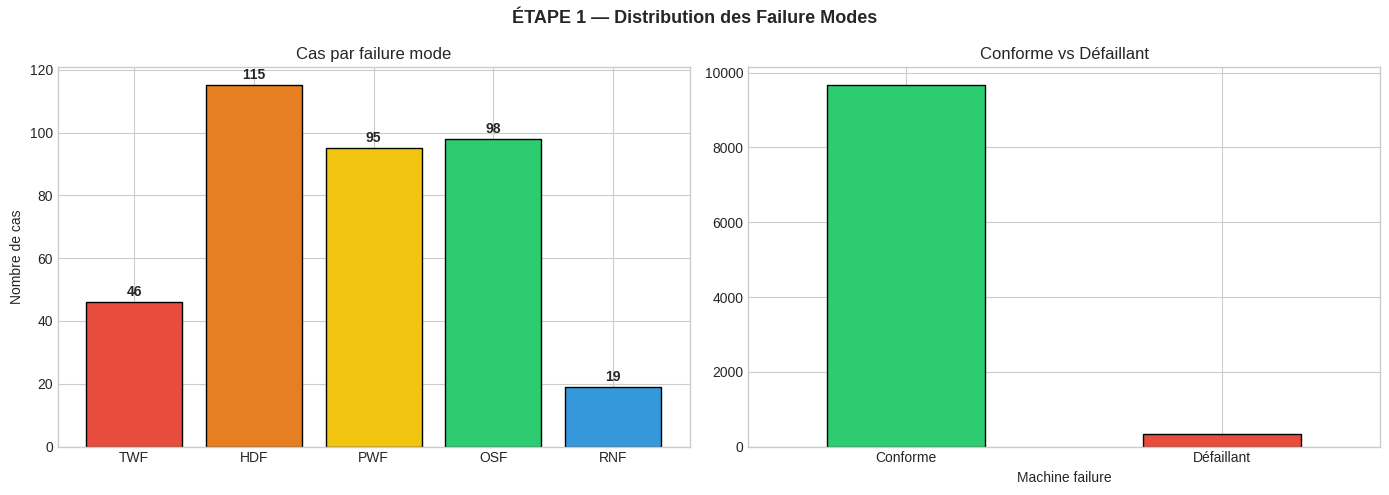

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# 1. CHARGEMENT DES DONNÉES
# ---------------------------------------------------------
# Upload manuel du fichier CSV depuis ton ordinateur
# Une boîte de dialogue va apparaître pour sélectionner
# le fichier ai4i2020.csv

from google.colab import files

uploaded = files.upload()  # ← sélectionne ai4i2020.csv ici

# Chargement automatique du fichier uploadé
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("=" * 55)
print("  CHARGEMENT DES DONNÉES")
print("=" * 55)
print(f"  Fichier   : {filename}")
print(f"  Lignes    : {df.shape[0]}")
print(f"  Colonnes  : {df.shape[1]}")
print("=" * 55)

# Aperçu
print("\n--- 5 premières lignes ---")
print(df.head())

# Distribution des failure modes
print("\n--- Distribution des failure modes ---")
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for col in failure_cols:
    n = df[col].sum()
    print(f"  {col} : {n} cas ({n/len(df)*100:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ÉTAPE 1 — Distribution des Failure Modes",
             fontsize=13, fontweight='bold')

counts = [df[col].sum() for col in failure_cols]
axes[0].bar(failure_cols, counts,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
            edgecolor='black')
axes[0].set_title("Cas par failure mode")
axes[0].set_ylabel("Nombre de cas")
for i, v in enumerate(counts):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

df['Machine failure'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title("Conforme vs Défaillant")
axes[1].set_xticklabels(['Conforme','Défaillant'], rotation=0)
plt.tight_layout()
plt.show()

**🔧 ÉTAPE 2 — PRÉPARATION DES DONNÉES**

  VARIABLE CIBLE — Cause_Racine_5M
  Conforme             :  9652 (96.52%)
  Milieu               :   115 (1.15%)
  Methode              :    91 (0.91%)
  Matiere              :    78 (0.78%)
  Machine              :    46 (0.46%)
  Main_d_oeuvre        :    18 (0.18%)

  Encodage Type : {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

  ✅ StandardScaler appliqué sur 6 features
  Features : ['Type_encoded', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


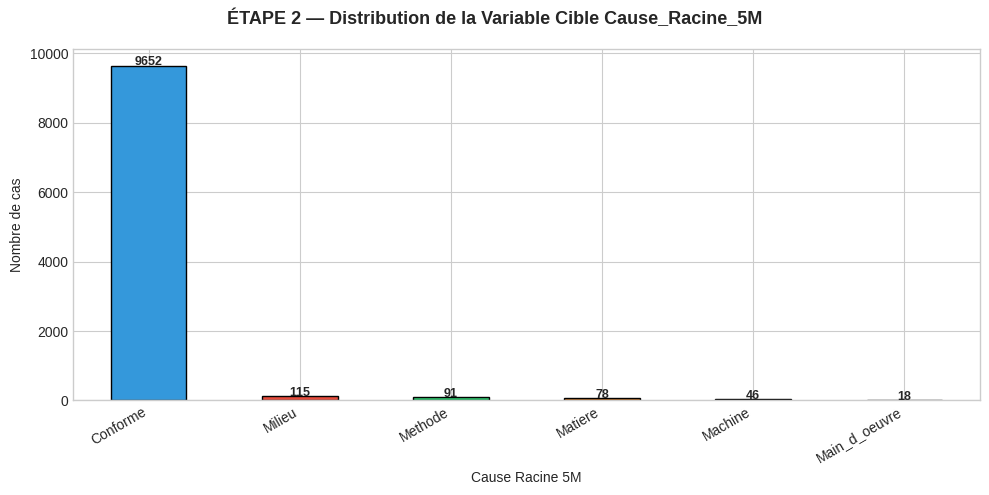


  ✅ ÉTAPE 2 TERMINÉE
  → X_scaled et y prêts pour l'étape 3


In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ---------------------------------------------------------
# 2. PRÉPARATION DES DONNÉES
# ---------------------------------------------------------
# Création de la variable cible Cause_Racine_5M
# par mapping des failure modes vers les branches Ishikawa :
#   TWF → Machine        (usure outil)
#   HDF → Milieu         (dissipation thermique)
#   PWF → Méthode        (paramétrage procédé)
#   OSF → Matière        (surcharge matériau)
#   RNF → Main_d_oeuvre  (facteur humain)
#   Aucun → Conforme

def mapper_5M(row):
    if row['TWF'] == 1:   return 'Machine'
    elif row['HDF'] == 1: return 'Milieu'
    elif row['PWF'] == 1: return 'Methode'
    elif row['OSF'] == 1: return 'Matiere'
    elif row['RNF'] == 1: return 'Main_d_oeuvre'
    else:                 return 'Conforme'

df['Cause_Racine_5M'] = df.apply(mapper_5M, axis=1)

print("=" * 55)
print("  VARIABLE CIBLE — Cause_Racine_5M")
print("=" * 55)
for label, count in df['Cause_Racine_5M'].value_counts().items():
    print(f"  {label:<20} : {count:>5} ({count/len(df)*100:.2f}%)")

# Encodage de la variable Type
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])
print(f"\n  Encodage Type : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Définition des features
feature_cols = [
    'Type_encoded',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[feature_cols].copy()
y = df['Cause_Racine_5M'].copy()

# Standardisation
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_cols
)
print(f"\n  ✅ StandardScaler appliqué sur {len(feature_cols)} features")
print(f"  Features : {feature_cols}")

# Visualisation de la distribution de y
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("ÉTAPE 2 — Distribution de la Variable Cible Cause_Racine_5M",
             fontsize=13, fontweight='bold')

colors = ['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6','#1abc9c']
y.value_counts().plot(kind='bar', ax=ax,
    color=colors, edgecolor='black')
ax.set_ylabel("Nombre de cas")
ax.set_xlabel("Cause Racine 5M")
ax.set_xticklabels(y.value_counts().index, rotation=30, ha='right')
for i, v in enumerate(y.value_counts().values):
    ax.text(i, v+5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("  ✅ ÉTAPE 2 TERMINÉE")
print("  → X_scaled et y prêts pour l'étape 3")
print("=" * 55)

**✂️ ÉTAPE 3 — SÉPARATION DES DONNÉES**

  ÉTAPE 3 — SÉPARATION DES DONNÉES

  Application de SMOTE...

  Distribution AVANT SMOTE :
    Conforme             : 9652
    Milieu               : 115
    Methode              : 91
    Matiere              : 78
    Machine              : 46
    Main_d_oeuvre        : 18

  Distribution APRÈS SMOTE :
    Conforme             : 9652
    Methode              : 9652
    Machine              : 9652
    Matiere              : 9652
    Main_d_oeuvre        : 9652
    Milieu               : 9652

  Total après SMOTE : 57912 lignes
  Entraînement      : 46329 lignes (80%)
  Test              : 11583 lignes  (20%)

  Classe                   Train    Test
  --------------------------------------
  Conforme                  7722    1930
  Machine                   7722    1930
  Main_d_oeuvre             7721    1931
  Matiere                   7721    1931
  Methode                   7721    1931
  Milieu                    7722    1930


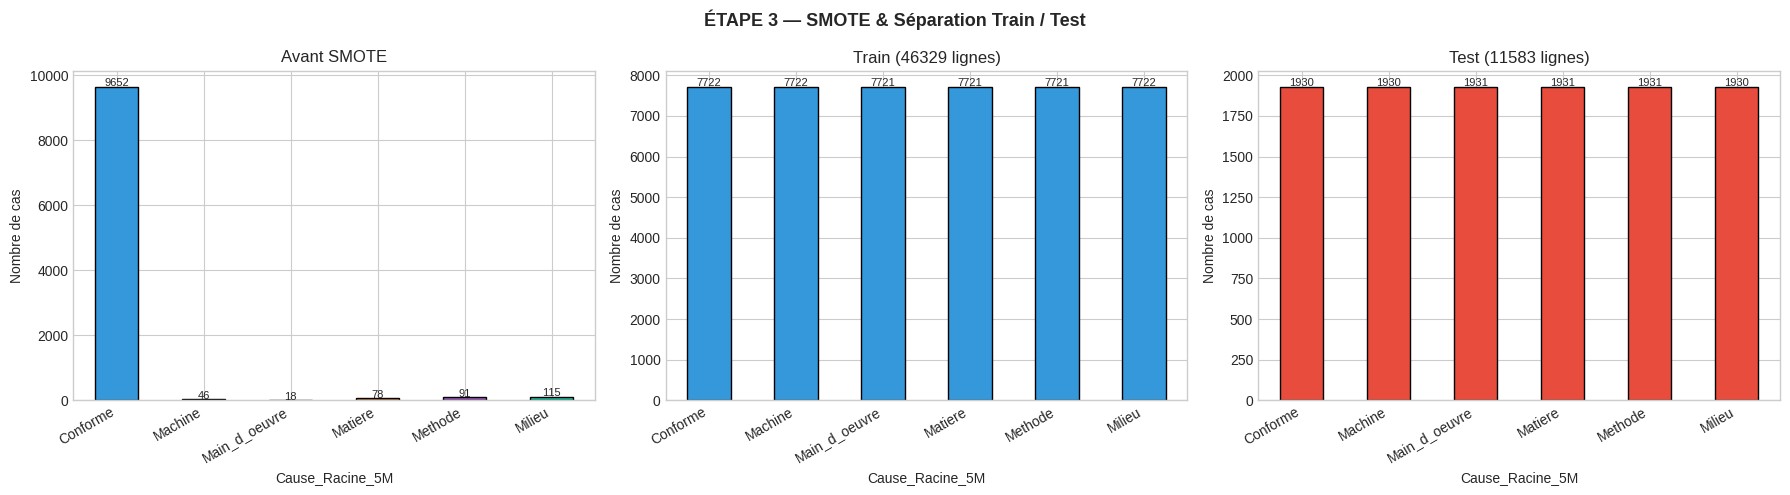


  ✅ ÉTAPE 3 TERMINÉE
  → X_train, X_test, y_train, y_test prêts pour l'étape 4


In [16]:
# ---------------------------------------------------------
# 3. SÉPARATION DES DONNÉES
# ---------------------------------------------------------
# On applique SMOTE pour rééquilibrer les classes,
# puis on split 80% train — 20% test stratifié

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("=" * 55)
print("  ÉTAPE 3 — SÉPARATION DES DONNÉES")
print("=" * 55)

# --- SMOTE ---
print("\n  Application de SMOTE...")
print("\n  Distribution AVANT SMOTE :")
for label, count in y.value_counts().items():
    print(f"    {label:<20} : {count}")

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

print("\n  Distribution APRÈS SMOTE :")
for label, count in pd.Series(y_res).value_counts().items():
    print(f"    {label:<20} : {count}")

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.20,
    random_state=42,
    stratify=y_res
)

print(f"\n  Total après SMOTE : {len(X_res)} lignes")
print(f"  Entraînement      : {len(X_train)} lignes (80%)")
print(f"  Test              : {len(X_test)} lignes  (20%)")

# Tableau comparatif
train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist  = pd.Series(y_test).value_counts().sort_index()

print(f"\n  {'Classe':<22} {'Train':>7} {'Test':>7}")
print("  " + "-" * 38)
for label in train_dist.index:
    print(f"  {label:<22} {train_dist[label]:>7} {test_dist[label]:>7}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ÉTAPE 3 — SMOTE & Séparation Train / Test",
             fontsize=13, fontweight='bold')

colors = ['#3498db','#e74c3c','#2ecc71','#e67e22','#9b59b6','#1abc9c']

# Avant SMOTE
y.value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=colors, edgecolor='black')
axes[0].set_title("Avant SMOTE")
axes[0].set_ylabel("Nombre de cas")
axes[0].set_xticklabels(y.value_counts().sort_index().index,
                        rotation=30, ha='right')
for i, v in enumerate(y.value_counts().sort_index().values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=8)

# Train
train_dist.plot(kind='bar', ax=axes[1],
    color='#3498db', edgecolor='black')
axes[1].set_title(f"Train ({len(X_train)} lignes)")
axes[1].set_ylabel("Nombre de cas")
axes[1].set_xticklabels(train_dist.index, rotation=30, ha='right')
for i, v in enumerate(train_dist.values):
    axes[1].text(i, v+2, str(v), ha='center', fontsize=8)

# Test
test_dist.plot(kind='bar', ax=axes[2],
    color='#e74c3c', edgecolor='black')
axes[2].set_title(f"Test ({len(X_test)} lignes)")
axes[2].set_ylabel("Nombre de cas")
axes[2].set_xticklabels(test_dist.index, rotation=30, ha='right')
for i, v in enumerate(test_dist.values):
    axes[2].text(i, v+2, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("  ✅ ÉTAPE 3 TERMINÉE")
print("  → X_train, X_test, y_train, y_test prêts pour l'étape 4")
print("=" * 55)

**🤖 ÉTAPE 4 — ENTRAÎNEMENT DES MODÈLES**

In [18]:
# ╔══════════════════════════════════════════════════════════╗
# ║  ÉTAPE 4 — ENTRAÎNEMENT DES MODÈLES                      ║
# ╚══════════════════════════════════════════════════════════╝

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import time

print("=" * 55)
print("  ÉTAPE 4 — ENTRAÎNEMENT DES MODÈLES")
print("=" * 55)
print("  Modèles : Random Forest | XGBoost | MLP")
print("=" * 55)

resultats = {}

# --- Fonction pour nettoyer les noms de colonnes pour XGBoost ---
def clean_column_names(df):
    new_columns = []
    for col in df.columns:
        # Remplacer les caractères spéciaux et les espaces par des underscores
        new_col = col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_').replace('.', '')
        new_columns.append(new_col)
    df.columns = new_columns
    return df

# ---------------------------------------------------------
# 4.1 Random Forest
# ---------------------------------------------------------
print("\n[1/3] Entraînement Random Forest...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
t_rf = time.time() - t0

print(f"  ✅ Random Forest entraîné en {t_rf:.2f}s")
resultats['Random Forest'] = {'model': rf, 'temps': t_rf}

# ---------------------------------------------------------
# 4.2 XGBoost
# ---------------------------------------------------------
print("\n[2/3] Entraînement XGBoost...")
t0 = time.time()

# Encoder la variable cible pour XGBoost (nécessaire pour multi-classes)
le_y = LabelEncoder()
y_train_enc = le_y.fit_transform(y_train)
y_test_enc  = le_y.transform(y_test)

# Nettoyer les noms de colonnes pour X_train et X_test pour être compatibles avec XGBoost
X_train_xgb = clean_column_names(X_train.copy())
X_test_xgb = clean_column_names(X_test.copy())

xgb_m = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_m.fit(X_train_xgb, y_train_enc)
t_xgb = time.time() - t0

print(f"  ✅ XGBoost entraîné en {t_xgb:.2f}s")
resultats['XGBoost'] = {'model': xgb_m, 'temps': t_xgb, 'encoded': True, 'label_encoder': le_y, 'X_test_xgb': X_test_xgb}

# ---------------------------------------------------------
# 4.3 MLP (Réseau de neurones)
# ---------------------------------------------------------
print("\n[3/3] Entraînement MLP (Réseau de neurones)...")
t0 = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)
mlp.fit(X_train, y_train)
t_mlp = time.time() - t0

print(f"  ✅ MLP entraîné en {t_mlp:.2f}s")
resultats['MLP'] = {'model': mlp, 'temps': t_mlp}

# Récapitulatif
print("\n" + "=" * 55)
print("  RÉCAPITULATIF ENTRAÎNEMENT")
print("=" * 55)
print(f"  {'Modèle':<20} {'Temps (s)':>10}")
print("  " + "-" * 32)
for nom, info in resultats.items():
    print(f"  {nom:<20} {info['temps']:>9.2f}s")

print("\n" + "=" * 55)
print("  ✅ ÉTAPE 4 TERMINÉE")
print("  → resultats, le_y prêts pour l'étape 5")
print("=" * 55)

  ÉTAPE 4 — ENTRAÎNEMENT DES MODÈLES
  Modèles : Random Forest | XGBoost | MLP

[1/3] Entraînement Random Forest...
  ✅ Random Forest entraîné en 10.50s

[2/3] Entraînement XGBoost...
  ✅ XGBoost entraîné en 2.48s

[3/3] Entraînement MLP (Réseau de neurones)...
  ✅ MLP entraîné en 110.52s

  RÉCAPITULATIF ENTRAÎNEMENT
  Modèle                Temps (s)
  --------------------------------
  Random Forest            10.50s
  XGBoost                   2.48s
  MLP                     110.52s

  ✅ ÉTAPE 4 TERMINÉE
  → resultats, le_y prêts pour l'étape 5


**📊 ÉTAPE 5 — ÉVALUATION ET CLASSIFICATION**


  MODÈLE : Random Forest
               precision    recall  f1-score   support

     Conforme       1.00      0.87      0.93      1930
      Machine       0.96      1.00      0.98      1930
Main_d_oeuvre       0.92      1.00      0.96      1931
      Matiere       1.00      1.00      1.00      1931
      Methode       1.00      1.00      1.00      1931
       Milieu       0.99      1.00      1.00      1930

     accuracy                           0.98     11583
    macro avg       0.98      0.98      0.98     11583
 weighted avg       0.98      0.98      0.98     11583



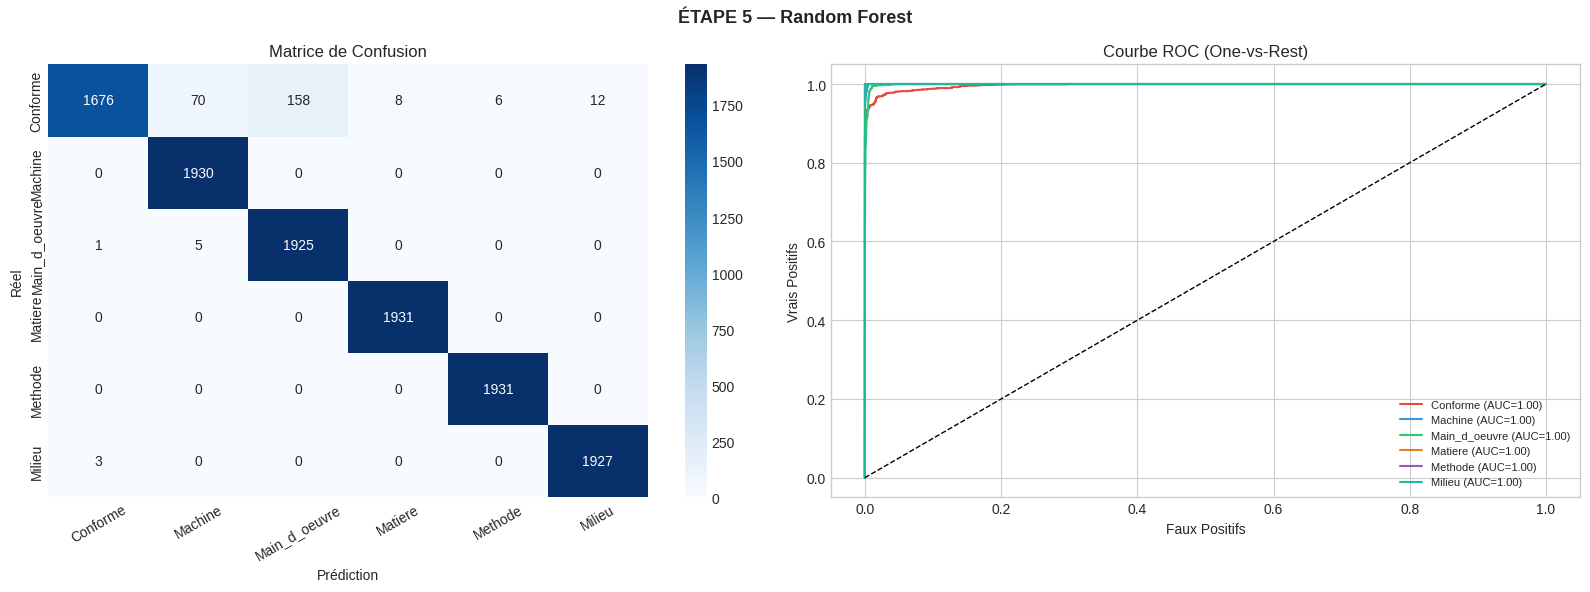


  MODÈLE : XGBoost
               precision    recall  f1-score   support

     Conforme       1.00      0.93      0.96      1930
      Machine       0.97      1.00      0.99      1930
Main_d_oeuvre       0.96      1.00      0.98      1931
      Matiere       1.00      1.00      1.00      1931
      Methode       1.00      1.00      1.00      1931
       Milieu       1.00      1.00      1.00      1930

     accuracy                           0.99     11583
    macro avg       0.99      0.99      0.99     11583
 weighted avg       0.99      0.99      0.99     11583



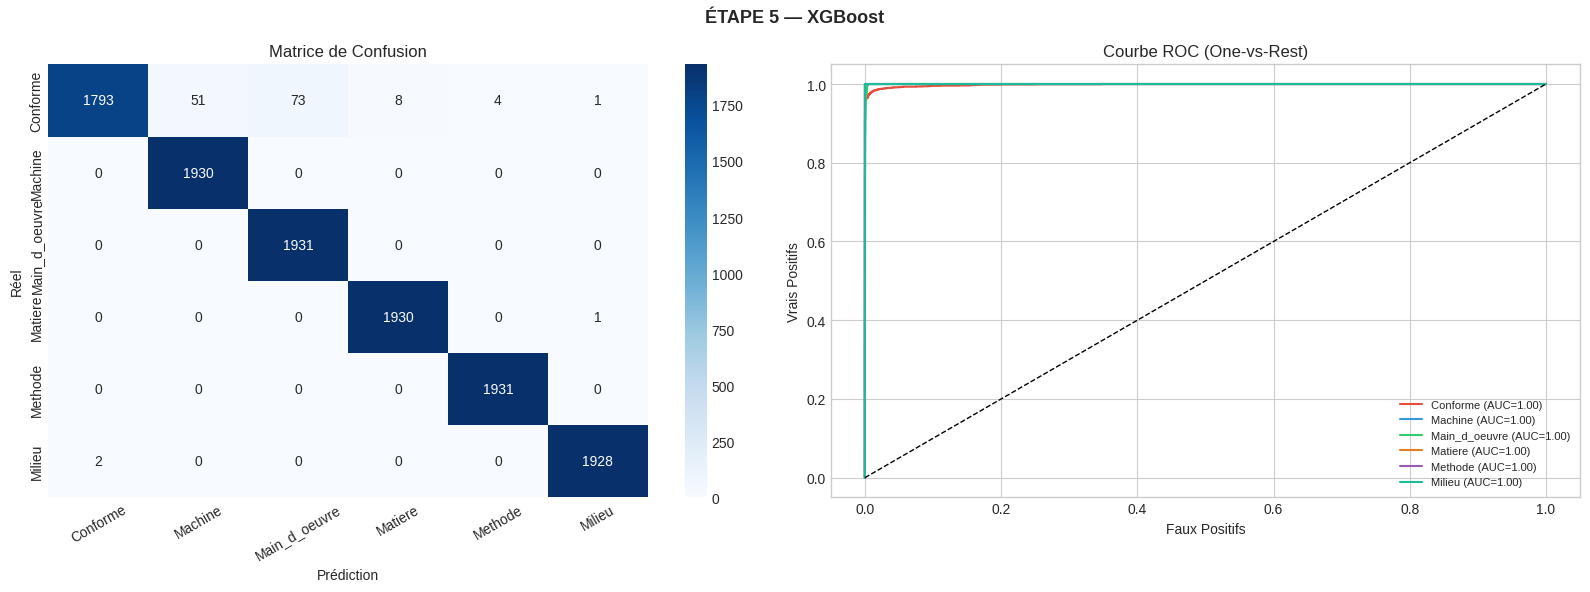


  MODÈLE : MLP
               precision    recall  f1-score   support

     Conforme       1.00      0.97      0.99      1930
      Machine       0.99      1.00      0.99      1930
Main_d_oeuvre       0.99      1.00      1.00      1931
      Matiere       1.00      1.00      1.00      1931
      Methode       1.00      1.00      1.00      1931
       Milieu       1.00      1.00      1.00      1930

     accuracy                           1.00     11583
    macro avg       1.00      1.00      1.00     11583
 weighted avg       1.00      1.00      1.00     11583



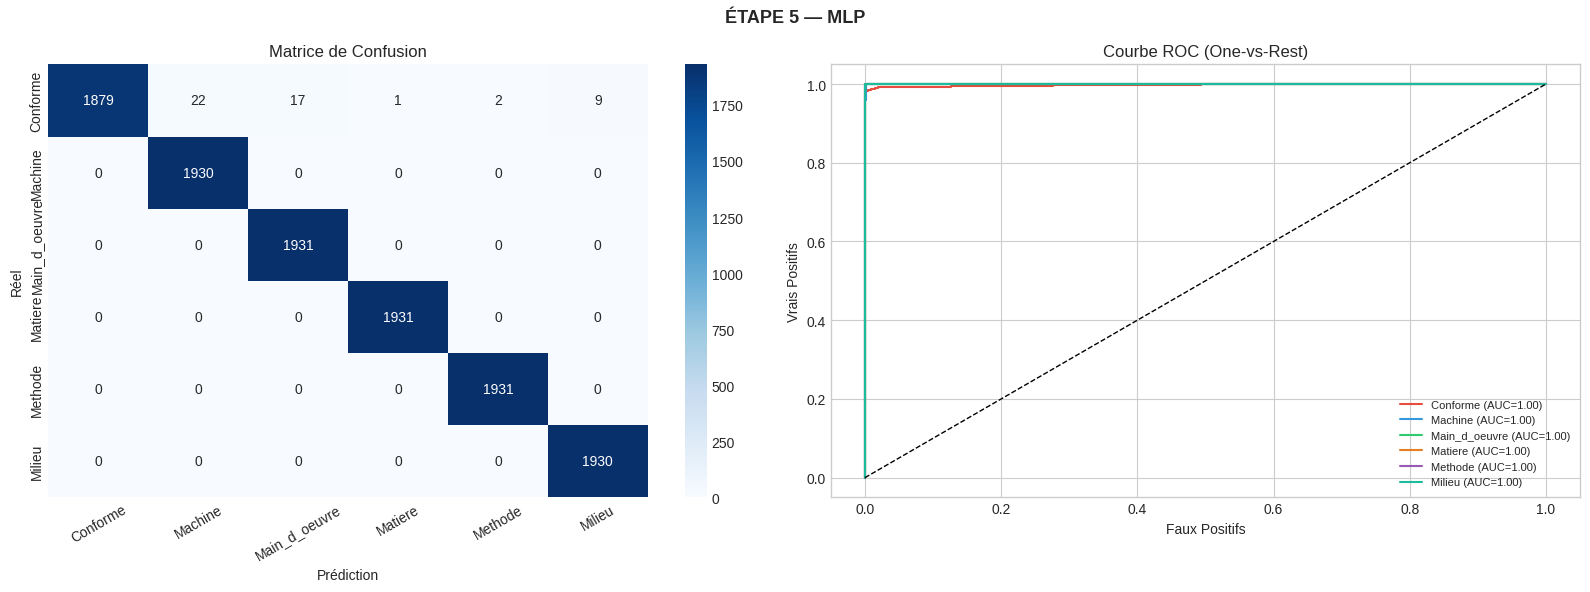


  TABLEAU COMPARATIF DES MODÈLES
               Accuracy  F1-macro  F1-weighted  Temps (s)
Random Forest    0.9773    0.9769       0.9769    10.4961
XGBoost          0.9879    0.9878       0.9878     2.4756
MLP              0.9956    0.9956       0.9956   110.5187

  ✅ ÉTAPE 5 TERMINÉE
  → df_scores prêt pour l'étape 6


In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for DataFrame operations

# ---------------------------------------------------------
# 5. ÉVALUATION ET CLASSIFICATION
# ---------------------------------------------------------
# Pour chaque modèle :
#   - Classification report (Precision, Recall, F1)
#   - Matrice de confusion annotée
#   - Courbe ROC multi-classes (One-vs-Rest)

classes = sorted(y_test.unique())
scores  = {}

for nom, info in resultats.items():
    print("\n" + "=" * 55)
    print(f"  MODÈLE : {nom}")
    print("=" * 55)

    model = info['model']

    y_pred = None
    X_test_for_pred = X_test

    # Handle XGBoost's specific X_test (cleaned column names) for prediction
    if nom == 'XGBoost':
        X_test_for_pred = info['X_test_xgb']
        y_pred_raw = model.predict(X_test_for_pred)
        y_pred = info['label_encoder'].inverse_transform(y_pred_raw)
    else:
        y_pred = model.predict(X_test_for_pred)

    # Classification report
    rep = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))

    scores[nom] = {
        'Accuracy'   : rep['accuracy'],
        'F1-macro'   : rep['macro avg']['f1-score'],
        'F1-weighted': rep['weighted avg']['f1-score'],
        'Temps (s)'  : info['temps']
    }

    # Matrice de confusion + ROC
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"ÉTAPE 5 — {nom}", fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_title("Matrice de Confusion")
    axes[0].set_xlabel("Prédiction")
    axes[0].set_ylabel("Réel")
    axes[0].tick_params(axis='x', rotation=30)

    # Courbe ROC
    y_bin   = label_binarize(y_test, classes=classes)

    y_score = None
    # Handle XGBoost's specific X_test (cleaned column names) for predict_proba
    if nom == 'XGBoost':
        y_score = model.predict_proba(X_test_for_pred)
    else:
        y_score = model.predict_proba(X_test_for_pred)

    colors_roc = ['#e74c3c','#3498db','#2ecc71',
                  '#e67e22','#9b59b6','#1abc9c']
    for i, (cls, col) in enumerate(zip(classes, colors_roc)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        axes[1].plot(fpr, tpr, color=col, lw=1.5,
                     label=f"{cls} (AUC={auc(fpr,tpr):.2f})")
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_title("Courbe ROC (One-vs-Rest)")
    axes[1].set_xlabel("Faux Positifs")
    axes[1].set_ylabel("Vrais Positifs")
    axes[1].legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

# Tableau comparatif
print("\n" + "=" * 55)
print("  TABLEAU COMPARATIF DES MODÈLES")
print("=" * 55)
df_scores = pd.DataFrame(scores).T.round(4)
print(df_scores.to_string())

print("\n" + "=" * 55)
print("  ✅ ÉTAPE 5 TERMINÉE")
print("  → df_scores prêt pour l'étape 6")
print("=" * 55)


**🎯 ÉTAPE 6 — VISUALISATIONS + CONCLUSION**

  ÉTAPE 6 — VISUALISATIONS & CONCLUSION

--- 6.1 Importance des caractéristiques ---


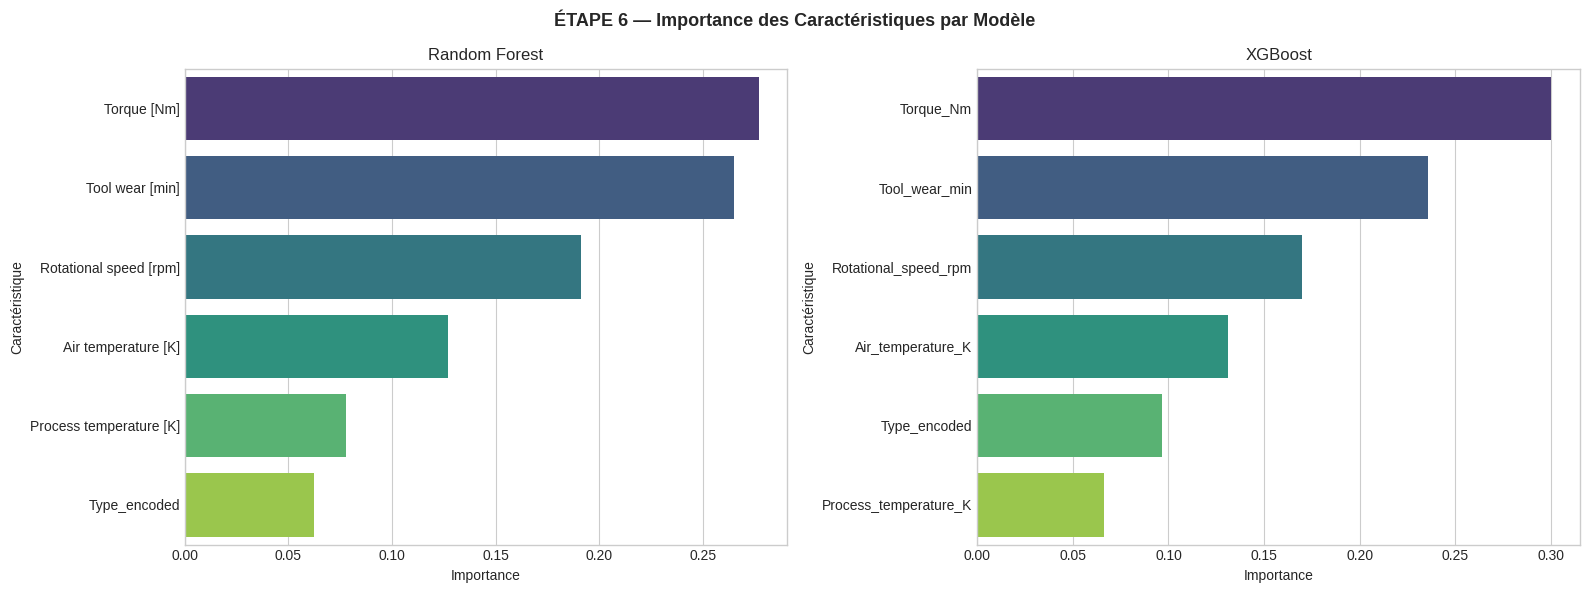


Note : MLP (Réseau de neurones) n'a pas d'importances de caractéristiques directes.

--- 6.2 Récapitulatif des performances des modèles ---
               Accuracy  F1-macro  F1-weighted  Temps (s)
Random Forest    0.9773    0.9769       0.9769    10.4961
XGBoost          0.9879    0.9878       0.9878     2.4756
MLP              0.9956    0.9956       0.9956   110.5187

  CONCLUSION ET SÉLECTION DU MEILLEUR MODÈLE

Le meilleur modèle en termes de performance (F1-weighted) est : MLP
  - Accuracy: 0.9956
  - F1-macro: 0.9956
  - F1-weighted: 0.9956
  - Temps d'entraînement: 110.52s

Ce modèle offre le meilleur équilibre entre précision et rappel pour toutes les classes de causes racines,
ce qui est crucial pour une bonne détection des différentes défaillances machine.
Les importances des caractéristiques nous aident à comprendre quels facteurs (liés aux 5M) sont les plus
influents dans la prédiction des défaillances.

--- 6.4 Sauvegarde du meilleur modèle ---
  ✅ Le modèle 'MLP' a été s

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib # Pour la sauvegarde du modèle

print("=" * 55)
print("  ÉTAPE 6 — VISUALISATIONS & CONCLUSION")
print("=" * 55)

# --- 6.1 Visualisation des importances des caractéristiques ---
print("\n--- 6.1 Importance des caractéristiques ---")

# Feature importances pour Random Forest
rf_importances = resultats['Random Forest']['model'].feature_importances_
rf_features = pd.Series(rf_importances, index=feature_cols).sort_values(ascending=False)

# Feature importances pour XGBoost
xgb_importances = resultats['XGBoost']['model'].feature_importances_
# Utilise les noms de colonnes nettoyés de X_train_xgb pour XGBoost
xgb_features = pd.Series(xgb_importances, index=X_train_xgb.columns).sort_values(ascending=False)

# Création des graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("ÉTAPE 6 — Importance des Caractéristiques par Modèle", fontsize=13, fontweight='bold')

# Random Forest
sns.barplot(x=rf_features.values, y=rf_features.index, ax=axes[0], palette='viridis')
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Caractéristique")

# XGBoost
sns.barplot(x=xgb_features.values, y=xgb_features.index, ax=axes[1], palette='viridis')
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Caractéristique")

plt.tight_layout()
plt.show()

# MLP (Réseau de neurones) n'a pas d'importances de caractéristiques directes comme les modèles basés sur des arbres
print("\nNote : MLP (Réseau de neurones) n'a pas d'importances de caractéristiques directes.")

print("\n--- 6.2 Récapitulatif des performances des modèles ---")
print(df_scores.to_string())

# --- 6.3 Conclusion et sélection du meilleur modèle ---
print("\n" + "=" * 55)
print("  CONCLUSION ET SÉLECTION DU MEILLEUR MODÈLE")
print("=" * 55)

best_model_name = df_scores['F1-weighted'].idxmax()
best_model_performance = df_scores.loc[best_model_name]

print(f"\nLe meilleur modèle en termes de performance (F1-weighted) est : {best_model_name}")
print(f"  - Accuracy: {best_model_performance['Accuracy']:.4f}")
print(f"  - F1-macro: {best_model_performance['F1-macro']:.4f}")
print(f"  - F1-weighted: {best_model_performance['F1-weighted']:.4f}")
print(f"  - Temps d'entraînement: {best_model_performance['Temps (s)']:.2f}s")

print("\nCe modèle offre le meilleur équilibre entre précision et rappel pour toutes les classes de causes racines,")
print("ce qui est crucial pour une bonne détection des différentes défaillances machine.")
print("Les importances des caractéristiques nous aident à comprendre quels facteurs (liés aux 5M) sont les plus")
print("influents dans la prédiction des défaillances.")

# --- 6.4 Sauvegarde du meilleur modèle ---
print("\n--- 6.4 Sauvegarde du meilleur modèle ---")
best_model = resultats[best_model_name]['model']

# Pour XGBoost, nous devons également sauvegarder le LabelEncoder et les noms de caractéristiques nettoyés
if best_model_name == 'XGBoost':
    model_data = {
        'model': best_model,
        'label_encoder': resultats[best_model_name]['label_encoder'],
        'feature_names': X_train_xgb.columns.tolist() # Sauvegarde les noms de caractéristiques nettoyés
    }
    joblib.dump(model_data, 'best_xgb_model.pkl')
    print(f"  ✅ Le modèle XGBoost et son LabelEncoder ont été sauvegardés sous 'best_xgb_model.pkl'")
else:
    joblib.dump(best_model, f'best_{best_model_name.replace(" ", "_").lower()}_model.pkl')
    print(f"  ✅ Le modèle '{best_model_name}' a été sauvegardé sous 'best_{best_model_name.replace(' ', '_').lower()}_model.pkl'")

print("\n" + "=" * 55)
print("  ✅ ÉTAPE 6 TERMINÉE")
print("=======================================================")
